### **Module End  Assignment: Python For Data Analysis**
## Social Media Engagement Analytics

# **Project Title: Social Media Engagement Analytics Using Python**
Problem Statement
Social media platforms generate massive volumes of engagement data—likes, comments, shares, impressions, watch time, and more. Analyzing such data helps companies understand user behavior, identify trends, and improve content performance.
In this assignment, you will work with a social media dataset containing social media engagement metrics. The task involves data cleaning, transformation, NumPy/Pandas operations, exploratory data analysis, visualizations, and generating insights.


**Assignment Tasks**
**Task 1 — Data Import & Setup**


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#import csv file
from google.colab import files
uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [ ]:
df= pd.read_csv("social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
#Check/convert data types

print(df.dtypes)

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [ ]:
#Convert the date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'])

print(df['posted_at'].dtype)

datetime64[ns]


/tmp/ipykernel_3423/1545193388.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


In [ ]:
#Use NumPy arrays for basic array operations
likes_array = np.array(df['likes'])

print("Likes array:")
print(likes_array[:10])

#basic array operations
print("\nNumPy Operations:")
print("Total Likes:", np.nansum(likes_array))
print("Average Likes:", np.nanmean(likes_array))
print("Maximum Likes:", np.nanmax(likes_array))
print("Minimum Likes:", np.nanmin(likes_array))

engagement_array = df[['likes', 'comments', 'shares']].to_numpy()

print("\nEngagement Array:")
print(engagement_array[:5])

print("\nEngagement Array Shape:")
print(engagement_array.shape)

Likes array:
[ 7011. 11750.  4862.  5350. 12682. 12535. 11703.  9611.    nan 14106.]

NumPy Operations:
Total Likes: 49019162.0
Average Likes: 10107.043711340206
Maximum Likes: 19998.0
Minimum Likes: 10.0

Engagement Array:
[[ 7011.   354.  1157.]
 [11750.  2606.  1807.]
 [ 4862.   344.   955.]
 [ 5350.  1083.  1049.]
 [12682.  2735.  1300.]]

Engagement Array Shape:
(5000, 3)


**Task 2 — Data Cleaning**


In [ ]:
#Missing Data
#Detect missing values (isnull(), isna())
#isnull
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
#isna
print("Missing values using isna():")
print(df.isna().sum())

Missing values using isna():
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
#Handle using: dropna(), fillna(), median/mode, forward/backward-fill

numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

#median
#==============================
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

#mode
#==============================
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

#dropna
#==============================
df_drop = df.dropna()

print("Original shape:", df.shape)
print("Shape after dropna:", df_drop.shape)

#forwardfill
#===============================
df_ffill = df.ffill()

print("Missing values after forward-fill:")
print(df_ffill.isnull().sum())

#backwardfill
#===============================
df_bfill = df.bfill()

print("Missing values after backward-fill:")
print(df_bfill.isnull().sum())

print("Missing values after cleaning:")
print(df.isnull().sum())
print("Total missing values:", df.isnull().sum().sum())


Numerical columns:
Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')

Categorical columns:
Index(['gender', 'country', 'post_type', 'post_category', 'device_type',
       'sentiment', 'hashtags'],
      dtype='object')
Original shape: (5000, 19)
Shape after dropna: (5000, 19)
Missing values after forward-fill:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64
Missing values after backward-fill:
user_id             0
age                 0
gender              0
country             0
post

In [ ]:
#Duplicate Handling
#Identify & remove duplicates
#Identify duplicate rows
#==========================
print("Number of duplicate rows:", df.duplicated().sum())

#Display duplicate rows
#==========================
print("\nDuplicate rows:")
print(df[df.duplicated()])

#Remove duplicate rows
#=========================
df = df.drop_duplicates()

#Display new shape
#=========================
print("\nShape after removing duplicates:")
print(df.shape)

#Verify duplicates are removed
print("\nDuplicates remaining:")
print(df.duplicated().sum())



Number of duplicate rows: 0

Duplicate rows:
Empty DataFrame
Columns: [user_id, age, gender, country, post_id, post_type, post_category, likes, comments, shares, watch_time_sec, impression_count, posted_at, follower_count, is_verified, device_type, sentiment, hashtags, engagement_rate]
Index: []

Shape after removing duplicates:
(5000, 19)

Duplicates remaining:
0


In [ ]:
#Data Formatting
#Fix incorrect data types
#Standardize categories (e.g., gender labels)
#Correct unrealistic values in likes, comments, shares

#Feature Cleaning
#Extract hashtag count
#Clean sentiment labels

#Check data types
#===================================
print("Current data types:")
print(df.dtypes)

#Convert posted_at to datetime
#===================================
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

#Convert numerical columns to numeric column
numeric_columns = [
    'age',
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'follower_count',
    'engagement_rate']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Standardize gender
df['gender'] = df['gender'].astype(str).str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'm': 'Male',
    'male': 'Male',
    'man': 'Male',
    'f': 'Female',
    'female': 'Female',
    'woman': 'Female'})

print("\nGender categories:")
print(df['gender'].value_counts())

# Check negative values
print("\nNegative values before cleaning:")
print("Likes:", (df['likes'] < 0).sum())
print("Comments:", (df['comments'] < 0).sum())
print("Shares:", (df['shares'] < 0).sum())

# Replace negative values with 0
df.loc[df['likes'] < 0, 'likes'] = 0
df.loc[df['comments'] < 0, 'comments'] = 0
df.loc[df['shares'] < 0, 'shares'] = 0

# Verify
print("\nNegative values after cleaning:")
print("Likes:", (df['likes'] < 0).sum())
print("Comments:", (df['comments'] < 0).sum())
print("Shares:", (df['shares'] < 0).sum())

# FEATURE CLEANING
#Extract hashtag count
df['hashtag_count'] = df['hashtags'].fillna('').str.count('#')

print("\nHashtag count:")
print(df[['hashtags', 'hashtag_count']].head())


#Clean sentiment labels
df['sentiment'] = (
    df['sentiment']
    .astype(str)
    .str.strip()
    .str.lower())
df['sentiment'] = df['sentiment'].replace({
    'positive': 'Positive',
    'pos': 'Positive',
    'negative': 'Negative',
    'neg': 'Negative',
    'neutral': 'Neutral',
    'neu': 'Neutral'})

print("\nCleaned sentiment categories:")
print(df['sentiment'].value_counts())
# FINAL CHECK
print("\nFinal data types:")
print(df.dtypes)

print("\nFinal dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())


Current data types:
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object

Gender categories:
gender
Male      1849
other     1581
Female    1570
Name: count, dtype: int64

Negative values before cleaning:
Likes: 0
Comments: 0
Shares: 0

Negative values after cleaning:
Likes: 0
Comments: 0
Shares: 0

Hashtag count:
                hashtags  hashtag_count
0  #foodie #travel

**Task 3 — Data Exploration using Pandas**

In [ ]:
#View dataset structure using head(), tail(), shape, and columns.
#Check data types and info with info() and dtypes.
#Generate summary statistics using describe().
#Analyze categorical distributions using value_counts(), unique(), and nunique().
#Create a correlation matrix for numeric fields.
#Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

#VIEW DATASET STRUCTURE
#===============================
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

#DATA TYPES AND INFORMATION
#===============================

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

#SUMMARY STATISTICS
#==============================

print("\nSummary Statistics:")
print(df.describe())

print("\nComplete Summary:")
print(df.describe(include='all'))

# CATEGORICAL DISTRIBUTIONS
#===============================

print("\nPost Type Distribution:")
print(df['post_type'].value_counts())

print("\nGender Distribution:")
print(df['gender'].value_counts())

print("\nCountry Distribution:")
print(df['country'].value_counts())

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())


# Unique values
print("\nUnique Post Types:")
print(df['post_type'].unique())

print("\nUnique Countries:")
print(df['country'].unique())

print("\nUnique Sentiments:")
print(df['sentiment'].unique())


# Number of unique values
print("\nNumber of Unique Post Types:",
      df['post_type'].nunique())

print("Number of Unique Countries:",
      df['country'].nunique())

print("Number of Unique Sentiments:",
      df['sentiment'].nunique())

#CORRELATION MATRIX
#==================================

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

#GROUPBY ANALYSIS
#=================================

# Average likes by post type
avg_likes = df.groupby('post_type')['likes'].mean()

print("\nAverage Likes by Post Type:")
print(avg_likes)

# Average comments by post type
avg_comments = df.groupby('post_type')['comments'].mean()

print("\nAverage Comments by Post Type:")
print(avg_comments)


# Average shares by post type
avg_shares = df.groupby('post_type')['shares'].mean()

print("\nAverage Shares by Post Type:")
print(avg_shares)

#IMPRESSIONS BY COUNTRY
#================================

impressions_by_country = (
    df.groupby('country')['impression_count']
    .sum())

print("\nTotal Impressions by Country:")
print(impressions_by_country)

# Average impressions by country
avg_impressions = (
    df.groupby('country')['impression_count']
    .mean())
print("\nAverage Impressions by Country:")
print(avg_impressions)

#MULTIPLE METRICS BY POST TYPE
#=====================================

post_type_summary = df.groupby('post_type').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'impression_count': 'mean',
    'engagement_rate': 'mean'})
post_type_summary = post_type_summary.round(2)

print("\nPost Type Summary:")
print(post_type_summary)


First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   other  France   848877      text       fitness   5350.0   
4    16265  34.0   other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        Fals

**Task 4 — Data Wrangling**

In [ ]:
#Use merge, concat, or join if combining DataFrames.
#Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag_count.
#Perform groupby summaries by post_type, country, and sentiment.
import numpy as np
import pandas as pd

#CONCAT
#================================
# Split DataFrame into two parts
df_part1 = df.iloc[:2500]
df_part2 = df.iloc[2500:]

# Combine DataFrames
df_combined = pd.concat(
    [df_part1, df_part2],
    ignore_index=True)

print("Combined DataFrame shape:")
print(df_combined.shape)

#CREATE ENGAGEMENT SCORE
#================================

df['engagement_score'] = (
    df['likes'] +
    df['comments'] +
    df['shares'])
print("\nEngagement Score:")
print(df[
    ['likes', 'comments', 'shares', 'engagement_score']
].head())

# 3. LOG-TRANSFORMED METRICS
#==================================

df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])
df['log_impressions'] = np.log1p(
    df['impression_count'])

print("\nLog-transformed metrics:")
print(df[
    ['likes', 'log_likes',
     'comments', 'log_comments',
     'shares', 'log_shares',
     'impression_count', 'log_impressions']].head())

#HASHTAG COUNT
#===================================

df['hashtag_count'] = (
    df['hashtags']
    .fillna('')
    .str.count('#'))

print("\nHashtag Count:")
print(df[['hashtags', 'hashtag_count']].head())

#GROUPBY — POST TYPE
#===================================

post_type_summary = df.groupby('post_type').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean',
    'engagement_rate': 'mean',
    'impression_count': 'mean'}).round(2)

print("\nSummary by Post Type:")
print(post_type_summary)

#GROUPBY — COUNTRY
#====================================

country_summary = df.groupby('country').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean',
    'engagement_rate': 'mean',
    'impression_count': 'sum'}).round(2)
print("\nSummary by Country:")
print(country_summary)

#GROUPBY — SENTIMENT
#====================================

sentiment_summary = df.groupby('sentiment').agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean',
    'engagement_rate': 'mean',
    'impression_count': 'mean'}).round(2)

print("\nSummary by Sentiment:")
print(sentiment_summary)

#SORT RESULTS
#=====================================

post_type_summary = post_type_summary.sort_values(
    'engagement_score',
    ascending=False)

sentiment_summary = sentiment_summary.sort_values(
    'engagement_score',
    ascending=False)

print("\nPost Types Ranked by Engagement Score:")
print(post_type_summary)

print("\nSentiments Ranked by Engagement Score:")
print(sentiment_summary)


Combined DataFrame shape:
(5000, 20)

Engagement Score:
     likes  comments  shares  engagement_score
0   7011.0     354.0  1157.0            8522.0
1  11750.0    2606.0  1807.0           16163.0
2   4862.0     344.0   955.0            6161.0
3   5350.0    1083.0  1049.0            7482.0
4  12682.0    2735.0  1300.0           16717.0

Log-transformed metrics:
     likes  log_likes  comments  log_comments  shares  log_shares  \
0   7011.0   8.855378     354.0      5.872118  1157.0    7.054450   
1  11750.0   9.371694    2606.0      7.865955  1807.0    7.499977   
2   4862.0   8.489411     344.0      5.843544   955.0    6.862758   
3   5350.0   8.585039    1083.0      6.988413  1049.0    6.956545   
4  12682.0   9.448018    2735.0      7.914252  1300.0    7.170888   

   impression_count  log_impressions  
0             44650        10.706632  
1             80216        11.292491  
2             44858        10.711280  
3             70455        11.162744  
4              6019       

**Task 5 — Statistical Analysis**

In [ ]:
#Compute descriptive stats for likes, comments, shares, watch_time, engagement_rate, followers:
#Mean, median, mode
#Standard deviation, variance
#Percentiles
#(Optional) Skewness and kurtosis

# TASK 5 — STATISTICAL ANALYSIS
# ==========================================

stats_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count']
stats_df = df[stats_columns]

# Mean
print("MEAN:")
print(stats_df.mean())

# Median
print("\nMEDIAN:")
print(stats_df.median())

# Mode
print("\nMODE:")
print(stats_df.mode().iloc[0])

# Standard Deviation
print("\nSTANDARD DEVIATION:")
print(stats_df.std())

# Variance
print("\nVARIANCE:")
print(stats_df.var())

# Percentiles
print("\nPERCENTILES:")
print(stats_df.quantile([0.25, 0.50, 0.75, 0.90]))

# Skewness
print("\nSKEWNESS:")
print(stats_df.skew())

# Kurtosis
print("\nKURTOSIS:")
print(stats_df.kurtosis())


# COMPLETE STATISTICAL SUMMARY
# ==========================================

statistical_summary = pd.DataFrame({
    'Mean': stats_df.mean(),
    'Median': stats_df.median(),
    'Mode': stats_df.mode().iloc[0],
    'Std_Dev': stats_df.std(),
    'Variance': stats_df.var(),
    '25th_Percentile': stats_df.quantile(0.25),
    '50th_Percentile': stats_df.quantile(0.50),
    '75th_Percentile': stats_df.quantile(0.75),
    '90th_Percentile': stats_df.quantile(0.90),
    'Skewness': stats_df.skew(),
    'Kurtosis': stats_df.kurtosis()})
print("\nCOMPLETE STATISTICAL SUMMARY:")
print(statistical_summary.round(2))


MEAN:
likes               10106.997400
comments             1502.039800
shares               1002.910600
watch_time_sec       4014.503200
engagement_rate         0.964356
follower_count     393698.224800
dtype: float64

MEDIAN:
likes               10105.500000
comments             1497.000000
shares               1012.000000
watch_time_sec       4034.500000
engagement_rate         0.253896
follower_count     388982.000000
dtype: float64

MODE:
likes               10105.500000
comments             1497.000000
shares               1012.000000
watch_time_sec        916.000000
engagement_rate         0.006363
follower_count     497502.000000
Name: 0, dtype: float64

STANDARD DEVIATION:
likes                5702.293017
comments              856.393312
shares                570.855200
watch_time_sec       2308.096459
engagement_rate         5.318029
follower_count     230927.884535
dtype: float64

VARIANCE:
likes              3.251615e+07
comments           7.334095e+05
shares             3.

**Task 6 — Data Visualization**

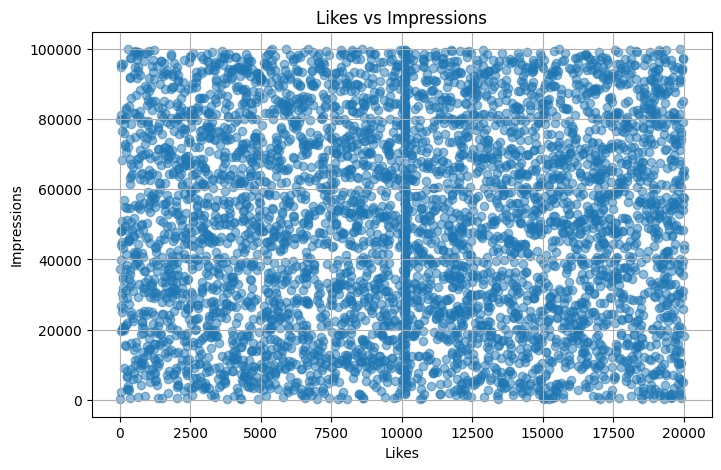

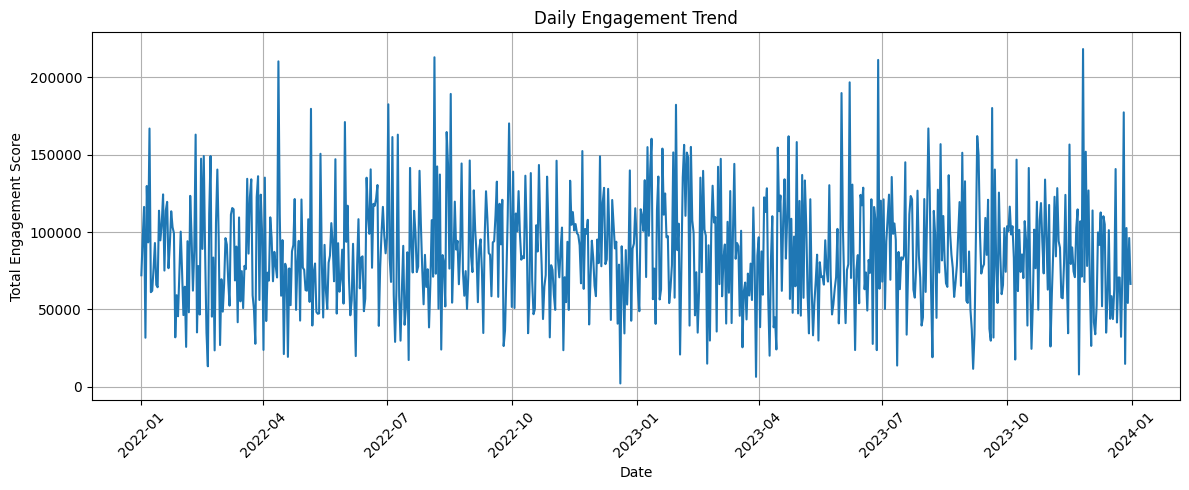

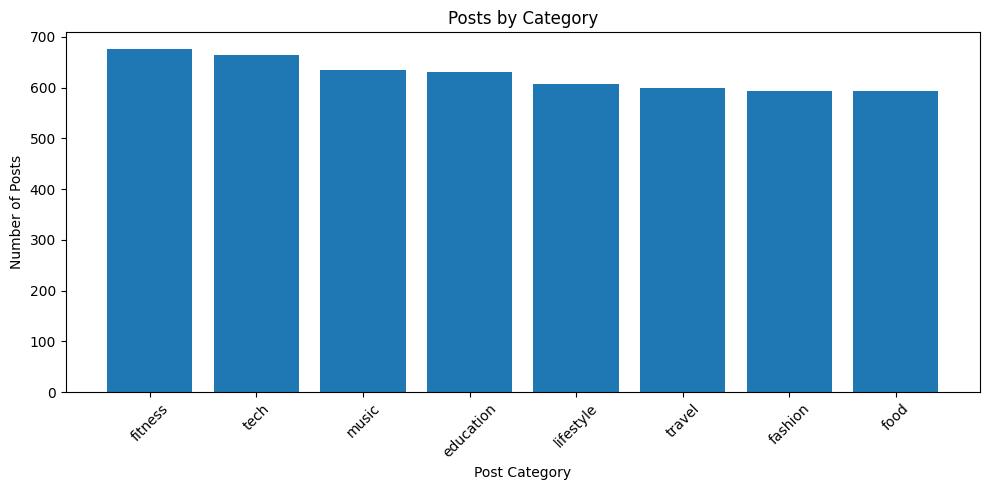

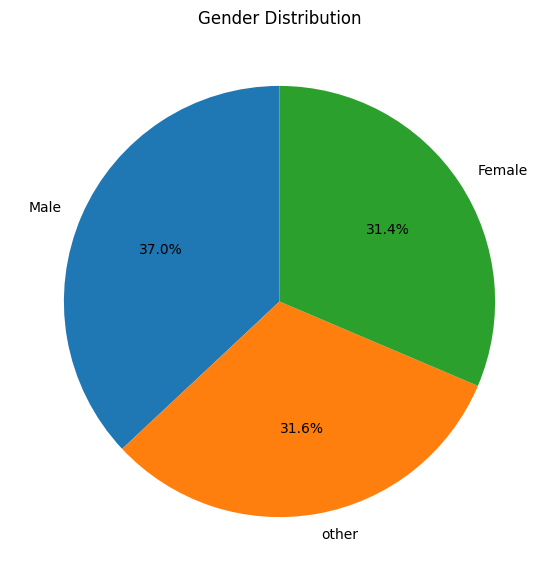

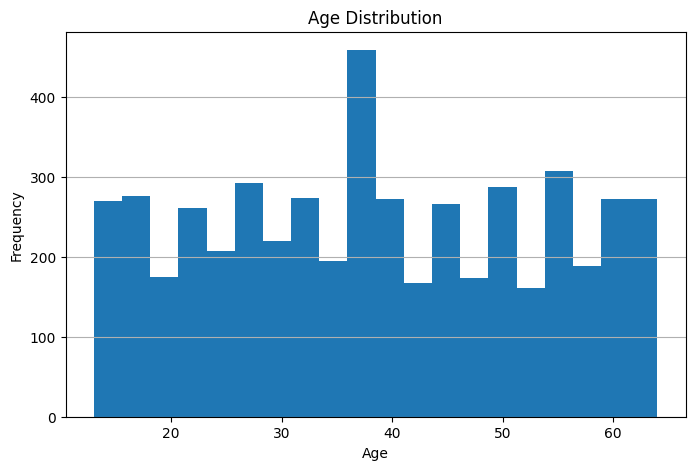

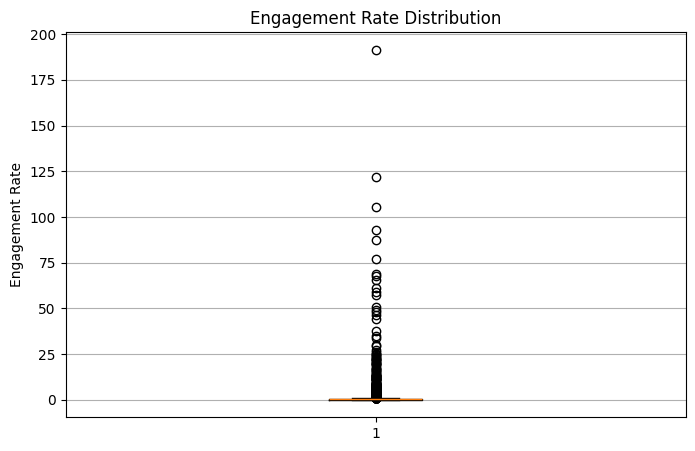

In [ ]:
#Matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# SCATTER — LIKES VS IMPRESSIONS
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df['likes'],
    df['impression_count'],
    alpha=0.5)
plt.title('Likes vs Impressions')
plt.xlabel('Likes')
plt.ylabel('Impressions')

plt.grid(True)
plt.show()

# LINE — DAILY ENGAGEMENT TREND
# ==========================================

df['date'] = df['posted_at'].dt.date

daily_engagement = (
    df.groupby('date')['engagement_score']
    .sum()
    .reset_index())

plt.figure(figsize=(12, 5))

plt.plot(
    daily_engagement['date'],
    daily_engagement['engagement_score'])
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Total Engagement Score')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# BAR — POSTS BY CATEGORY
# ==========================================

category_counts = df['post_category'].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(
    category_counts.index,
    category_counts.values)

plt.title('Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# PIE — GENDER DISTRIBUTION
# ==========================================

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90)

plt.title('Gender Distribution')
plt.show()

# HISTOGRAM — AGE
# ==========================================

plt.figure(figsize=(8, 5))

plt.hist(
    df['age'].dropna(),
    bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.grid(axis='y')
plt.show()

#BOX — ENGAGEMENT RATE
# ==========================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    df['engagement_rate'].dropna())

plt.title('Engagement Rate Distribution')
plt.ylabel('Engagement Rate')

plt.grid(axis='y')
plt.show()



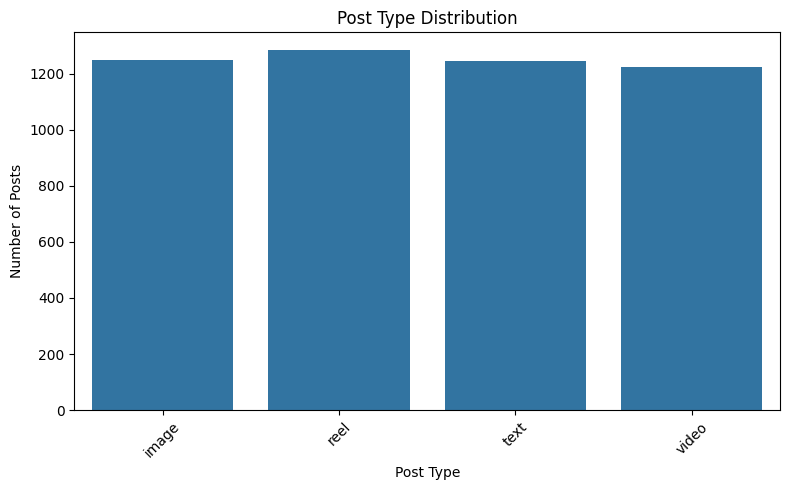

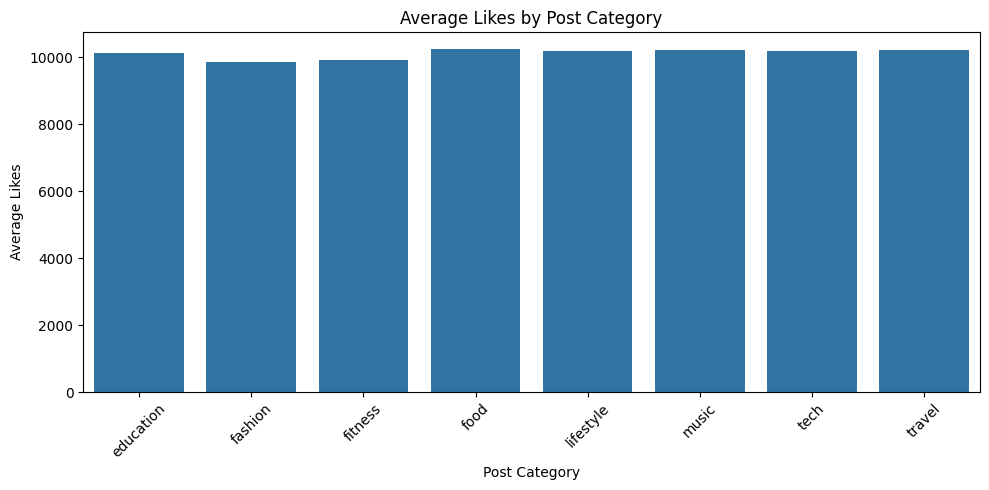

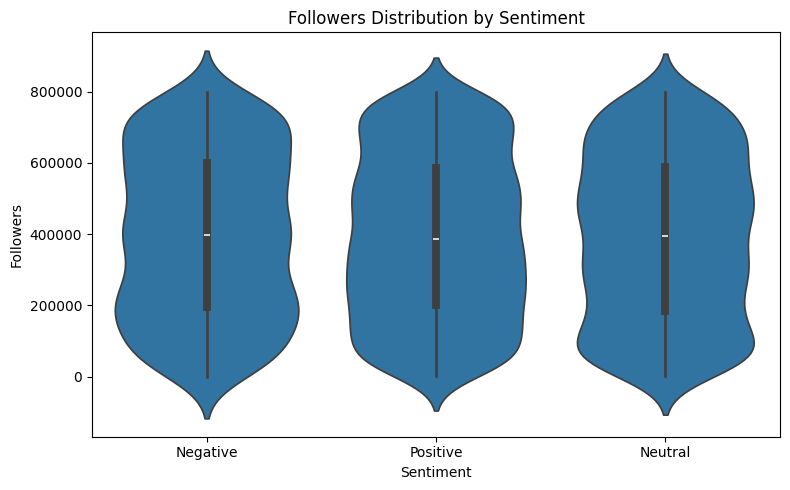

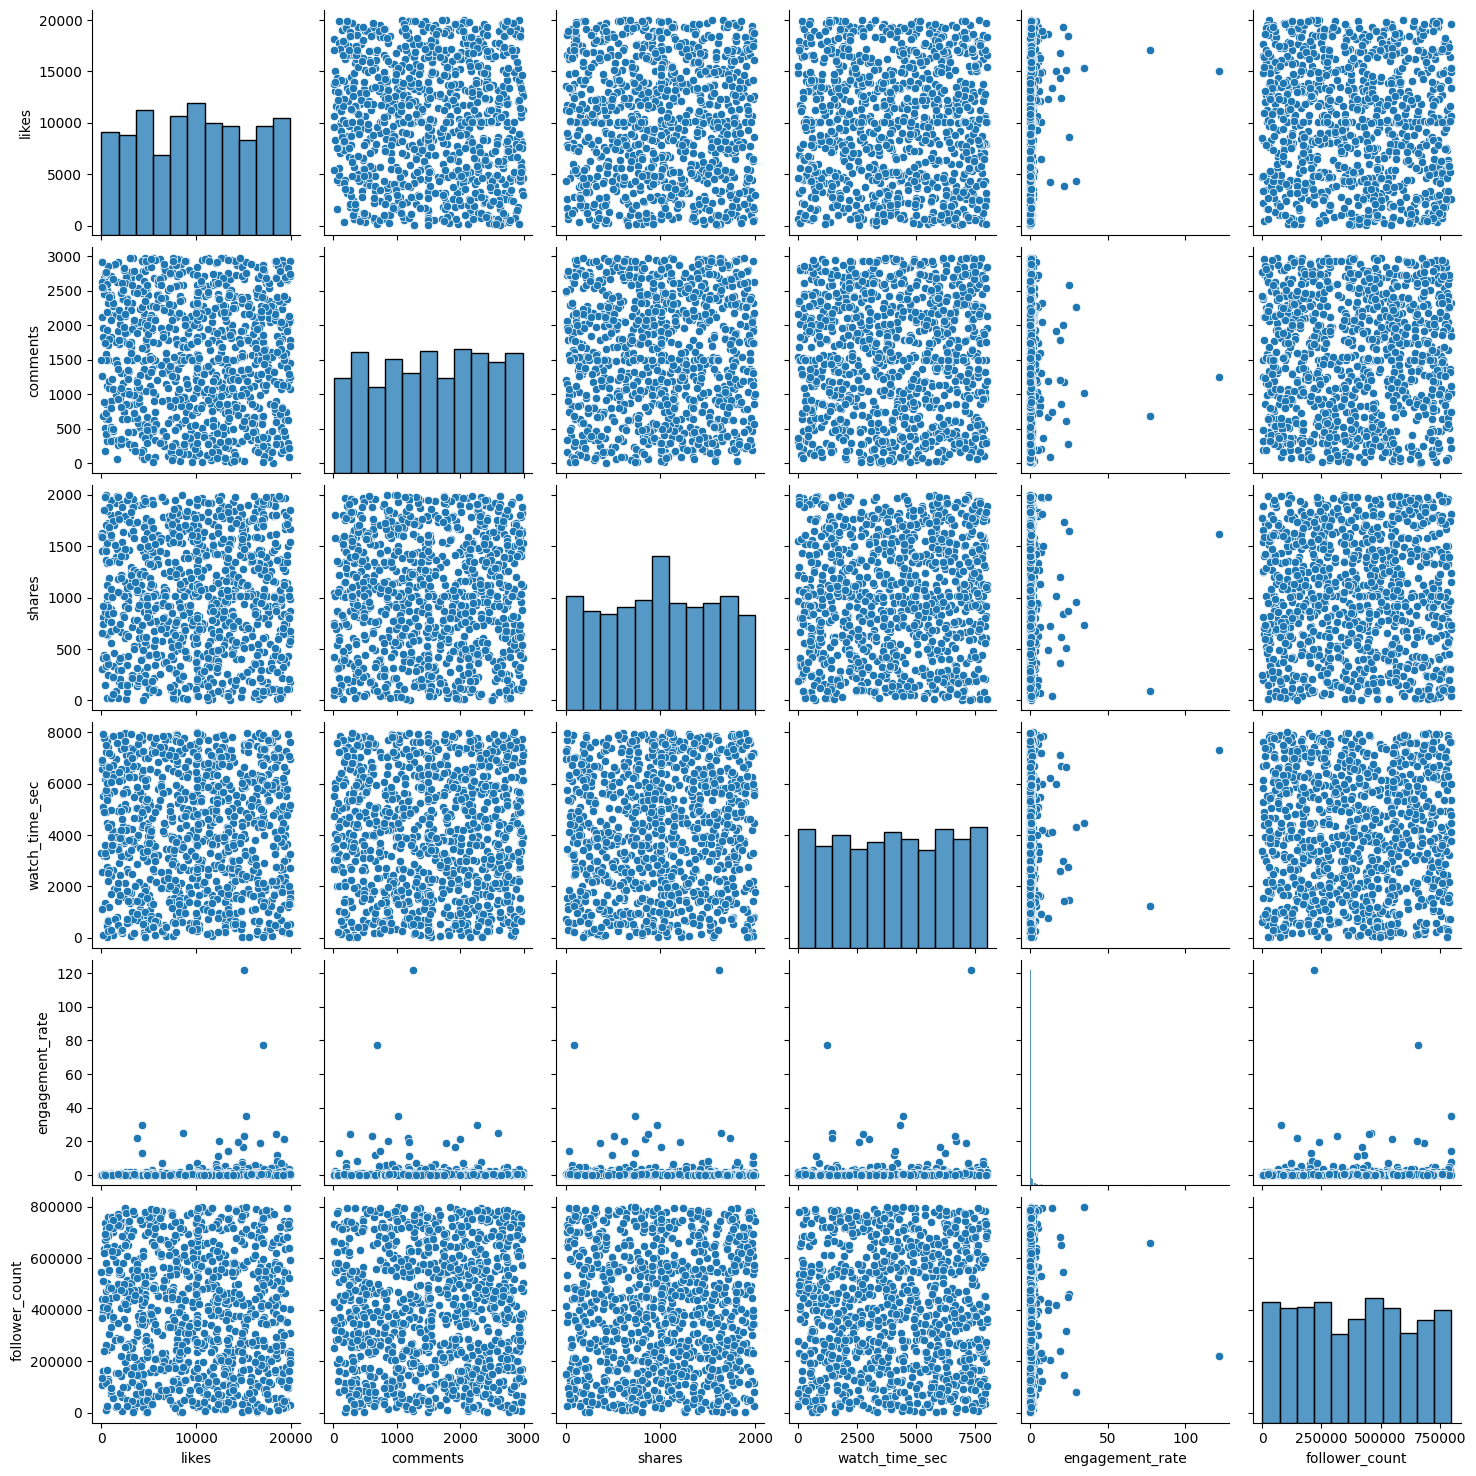

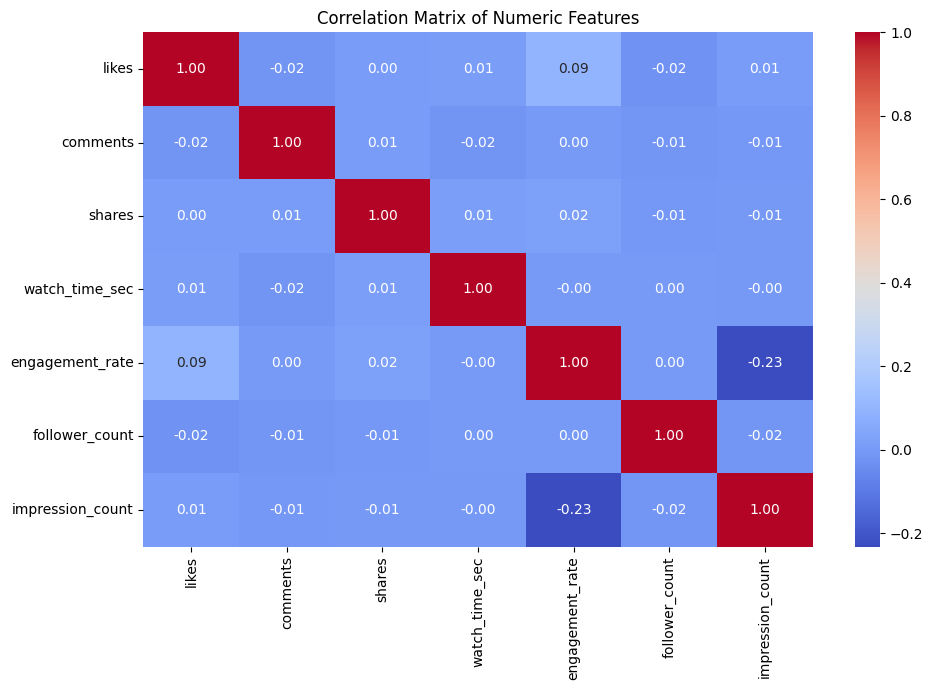

In [ ]:
#Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# COUNT PLOT — POST TYPE
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='post_type')
plt.title('Post Type Distribution')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# BAR PLOT — AVG LIKES BY CATEGORY
# ==========================================

category_likes = (
    df.groupby('post_category')['likes']
    .mean()
    .reset_index())

plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_likes,
    x='post_category',
    y='likes')

plt.title('Average Likes by Post Category')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# VIOLIN — FOLLOWERS VS SENTIMENT
# ==========================================

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count')
plt.title('Followers Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Followers')

plt.tight_layout()
plt.show()

# PAIR PLOT — NUMERIC FEATURES
# ==========================================

numeric_features = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count']

sns.pairplot(
    df[numeric_features].dropna().sample(
        1000,
        random_state=42))
plt.show()

# HEATMAP — CORRELATION MATRIX
# ==========================================

heatmap_features = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count',
    'impression_count']

correlation_matrix = df[heatmap_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm')

plt.title('Correlation Matrix of Numeric Features')

plt.tight_layout()
plt.show()


In [ ]:
#Plotly (Interactive)
!pip install plotly

import plotly.express as px
import pandas as pd

#INTERACTIVE BAR CHART- AVERAGE LIKE BY CATEGORY

category_likes = (
    df.groupby('post_category')['likes']
    .mean()
    .reset_index())
fig = px.bar(
    category_likes,
    x='post_category',
    y='likes',
    title='Average Likes by Post Category',
    labels={
        'post_category': 'Post Category',
        'likes': 'Average Likes'},text_auto='.2s')
fig.show()

In [ ]:
#INTERACTIVE LINE PLOT-DAILY ENGAGEMENT TREND
# Create daily engagement data
daily_engagement = (
    df.groupby('date')['engagement_score']
    .sum()
    .reset_index())

# Interactive line chart
fig = px.line(
    daily_engagement,
    x='date',
    y='engagement_score',
    title='Daily Engagement Trend',
    labels={
        'date': 'Date',
        'engagement_score': 'Total Engagement Score'},
    markers=True)
fig.show()

**Final insights**

# **Content Performance**
*Which post types have highest engagement?*

*   Video posts have the highest average engagement rate (1.122), followed by Text (1.065), Image (0.896), and Reel (0.783).
*   This indicates that video content performs best in terms of audience engagement.

*Best-performing content category?*

*   Food is the best-performing category with the highest average likes (10,230.59).
*   Fashion has the lowest average likes (9,835.16) among the categories.It is followed by Music (10,208.34) and Travel (10,198.95).
*   It is followed by Music (10,208.34) and Travel (10,198.95).

*Which countries have highest average engagement rate?*

*   Brazil has the highest average engagement rate (1.541).
*   It is followed by Australia (1.324) and France (1.146).
*   UAE also shows relatively high engagement (1.112).


# **User Trends**
*How age affects engagement*

*   Engagement varies considerably across different age groups.
*   Age 24 has the highest average engagement rate (2.897).
*   This is followed by age 55 (2.599) and age 51 (2.397)
*   The data suggests that engagement is not consistently increasing or decreasing with age; certain age groups show significantly higher engagement.

*Performance difference for verified accounts*

*   Verified accounts have a higher average engagement rate (1.054) compared with non-verified accounts (0.955).
*   This suggests that verified accounts receive approximately 10.4% higher engagement than non-verified accounts in this dataset.
*   Therefore, verified accounts perform slightly better in terms of audience engagement.










# **Behavioral Insights**
*Best time of day for impressions*

*   The dataset's posted_at column contains dates only, without a time component. Therefore, a specific best time of day cannot be determined from this dataset.List item
*   All 5,000 records have the time recorded as 00:00:00, so analyzing impressions by hour would not provide a meaningful result.List item
*   A dataset containing the actual posting time would be required to identify the best time of day for impressions.List item

*Device type impact on watch time*

*   Mobile users have the highest average watch time at approximately 4,087.83 seconds.
*   Tablet users average approximately 3,979.74 seconds, while Desktop users average approximately 3,974.79 seconds.
*   This shows that mobile users spend the most time watching content, making mobile the strongest device type for watch-time performance.









# **Sentiment Analysis**
*Which sentiment performs best?*

*   Negative sentiment posts perform best, with the highest average engagement rate of 1.038.
*   Neutral sentiment follows with an average engagement rate of 0.991.
*   Positive sentiment has the lowest average engagement rate at 0.955.

*Behavior of negative/neutral sentiment posts*

*   Negative posts receive higher average engagement (1.038) than neutral posts (0.991)
*   Negative posts also have higher average likes (10,211) and shares (1,007).
*   Neutral posts receive slightly more average comments (1,529) than negative posts (1,517).
*  The data suggests that negative and neutral content generates stronger engagement than positive content, with negative posts performing the best overall.




## **SUMMARY**

**Social Media Engagement Analysis **

This analysis was conducted to understand the major factors influencing social media engagement and audience behavior using a dataset of **5,000 social media posts**. Data cleaning, statistical analysis, and visualization techniques were used to identify meaningful patterns and trends.

*Content Performance*

The analysis found that **Video posts** generated the highest average engagement rate, showing that video is an effective format for attracting audience interaction. Among content categories, **Food** achieved the highest average number of likes. At the country level, **Brazil** recorded the highest average engagement rate, followed by **Australia and France**.

*User Trends*

Age-based analysis showed that engagement differs across age groups rather than following a simple increasing or decreasing pattern. **Users aged 24** recorded the highest average engagement rate. The analysis also showed that **verified accounts** achieved higher engagement than non-verified accounts, suggesting that account verification may be associated with stronger audience interaction.

*Behavioral Insights*

Device analysis revealed that **mobile users had the highest average watch time**, indicating that mobile platforms play an important role in content consumption. Although posting time was considered as part of the analysis, the dataset did not provide meaningful time-of-day information, so a reliable conclusion about the best posting time could not be made.

*Sentiment Analysis*

Sentiment analysis showed that **negative sentiment posts** achieved the highest average engagement rate, followed by neutral and positive posts. Negative posts also generated strong levels of likes and shares, suggesting that emotionally engaging content can attract greater audience interaction.




## **Finding**

The analysis demonstrates that social media engagement is influenced by multiple factors, including content format, category, location, age, account verification, device type, and sentiment. These findings highlight the importance of using data-driven strategies to select suitable content formats, understand target audiences, and improve social media engagement and reach.
